# Results figures

Every figure of thesis section 7, regenerated from the cached data produced by NB1-9 and the cluster sweeps. No transfer matrices are built here; each cell loads the caches, redoes the fits, and saves one figure. Rerunning the notebook after new cluster rungs land re-plots everything.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics, LsqFit
thesis_plot_theme!()

const V = load("../results/data/alcaraz_velocity.jld2", "v")
const M8 = load("../results/data/nb8_master.jld2", "done")
const CL = "../results/data/cluster"

# chord variable and helpers used by every entropy fit
W(t, T) = log((2T / pi) * sin(pi * t / T))
ph(z) = angle(-z)
dphw(a, b) = mod(a - b + pi, 2pi) - pi

load_arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath(CL, file), "done") if k[1] == label && !haskey(v, :error))

# re-derive the physical branch along a ladder with the robust selector
function robust_chain(arm)
    out = Dict{Float64,Tuple{Int,Bool}}()
    ref = nothing
    for T in sort(collect(keys(arm)))
        theta = arm[T].theta
        i0, rec = pick_phys_robust(theta, ref)
        out[T] = (i0, rec)
        rec && (ref = theta[i0])
    end
    return out
end

# follow the physical branch by predicting its unwrapped phase: the ±partner sits at the same
# modulus but ~π away, and the phase advance per rung can exceed π at large p, so neither modulus
# dominance nor nearest-complex tracking is safe on its own.
function phase_chain(arm)
    Ts = sort(collect(keys(arm)))
    out = Dict{Float64,Int}(); Phi = Dict{Float64,Float64}(); okT = Float64[]; cost = Dict{Float64,Float64}()
    slope = nothing; prevT = nothing; mprev = 0.0
    for (n, T) in enumerate(Ts)
        theta = arm[T].theta
        mags = abs.(theta)
        if n == 1
            i0 = argmax(mags)
            out[T] = i0; Phi[T] = ph(theta[i0]); cost[T] = 0.0; push!(okT, T)
            prevT = T; mprev = mags[i0]
            continue
        end
        # every block member is a candidate: near the ± degeneracy the partner can carry the
        # larger modulus, so only the predicted phase identifies the physical branch
        cand = [i for i in eachindex(theta) if abs(mags[i] - mprev) / mprev < 0.20]
        isempty(cand) && continue
        if slope === nothing
            # advance per rung can exceed π, so the wrapped step is ambiguous: seed with the
            # candidate advance that keeps the next rungs most consistent
            Tnext = [t for t in Ts if t > T][1:min(3, count(>(T), Ts))]
            bestadv = nothing; bestscore = Inf; besti = cand[1]
            for i in cand, kk in 0:2
                adv = dphw(ph(theta[i]), Phi[prevT]) + 2pi * kk
                adv <= 0.05 && continue
                sl = adv / (T - prevT); phi = Phi[prevT] + adv
                score = 0.0; pv = phi; pt = T
                for t2 in Tnext
                    pr = pv + sl * (t2 - pt)
                    bc2 = Inf
                    for tt in arm[t2].theta
                        b2 = ph(tt); k2 = round((pr - b2) / (2pi))
                        for k3 in (k2 - 1, k2, k2 + 1)
                            bc2 = min(bc2, abs(b2 + 2pi * k3 - pr))
                        end
                    end
                    score += bc2
                end
                score < bestscore && (bestscore = score; bestadv = adv; besti = i)
            end
            out[T] = besti; cost[T] = 0.0
            Phi[T] = Phi[prevT] + bestadv
        else
            pred = Phi[prevT] + slope * (T - prevT)
            best = cand[1]; bphi = 0.0; bcost = Inf
            for i in cand
                base = ph(theta[i])
                k = round((pred - base) / (2pi))
                for kk in (k - 1, k, k + 1)
                    phi = base + 2pi * kk
                    cst = abs(phi - pred)
                    cst < bcost && (bcost = cst; best = i; bphi = phi)
                end
            end
            bcost > 1.0 && continue              # no candidate matches the winding: skip the rung
            out[T] = best; Phi[T] = bphi; cost[T] = bcost
        end
        slope = (Phi[T] - Phi[prevT]) / (T - prevT)
        prevT = T; mprev = mags[out[T]]; push!(okT, T)
    end
    return out, Phi, okT, cost
end

mkpath("../results/imgs")
println("caches loaded; v(p) = ", V)

caches loaded; v(p) = Dict

(0.0 => 1.9772318589307316, 0.4 => 4.370725373666438, 0.3 => 3.7971521760836935, 0.5 => 4.928425829283448, 0.2 => 3.2072597236817915, 0.1 => 2.6007075791039935)


## The entropy route at the integrable point

Prediction: the Renyi-2 temporal entropy follows the chord profile with slope c/8 in the real part, and its imaginary part is flat at pi*c/16.

At the times we reach, the imaginary part sits above that asymptote by a finite-time correction that decays as T^(-1/2). Panel (c) therefore plots the plateau against T^(-1/2), where that correction is a straight line and the intercept is the asymptotic value. Reading c from the intercept is what removes the bias; the red star marks where the intercept would sit for c=1/2.

T= 6  plateau = 0.1287
T= 8  plateau = 0.1243


T=10  plateau = 0.1228
T=12  plateau = 0.1188
asymptotic πc/16 at c=1/2 = 0.0982


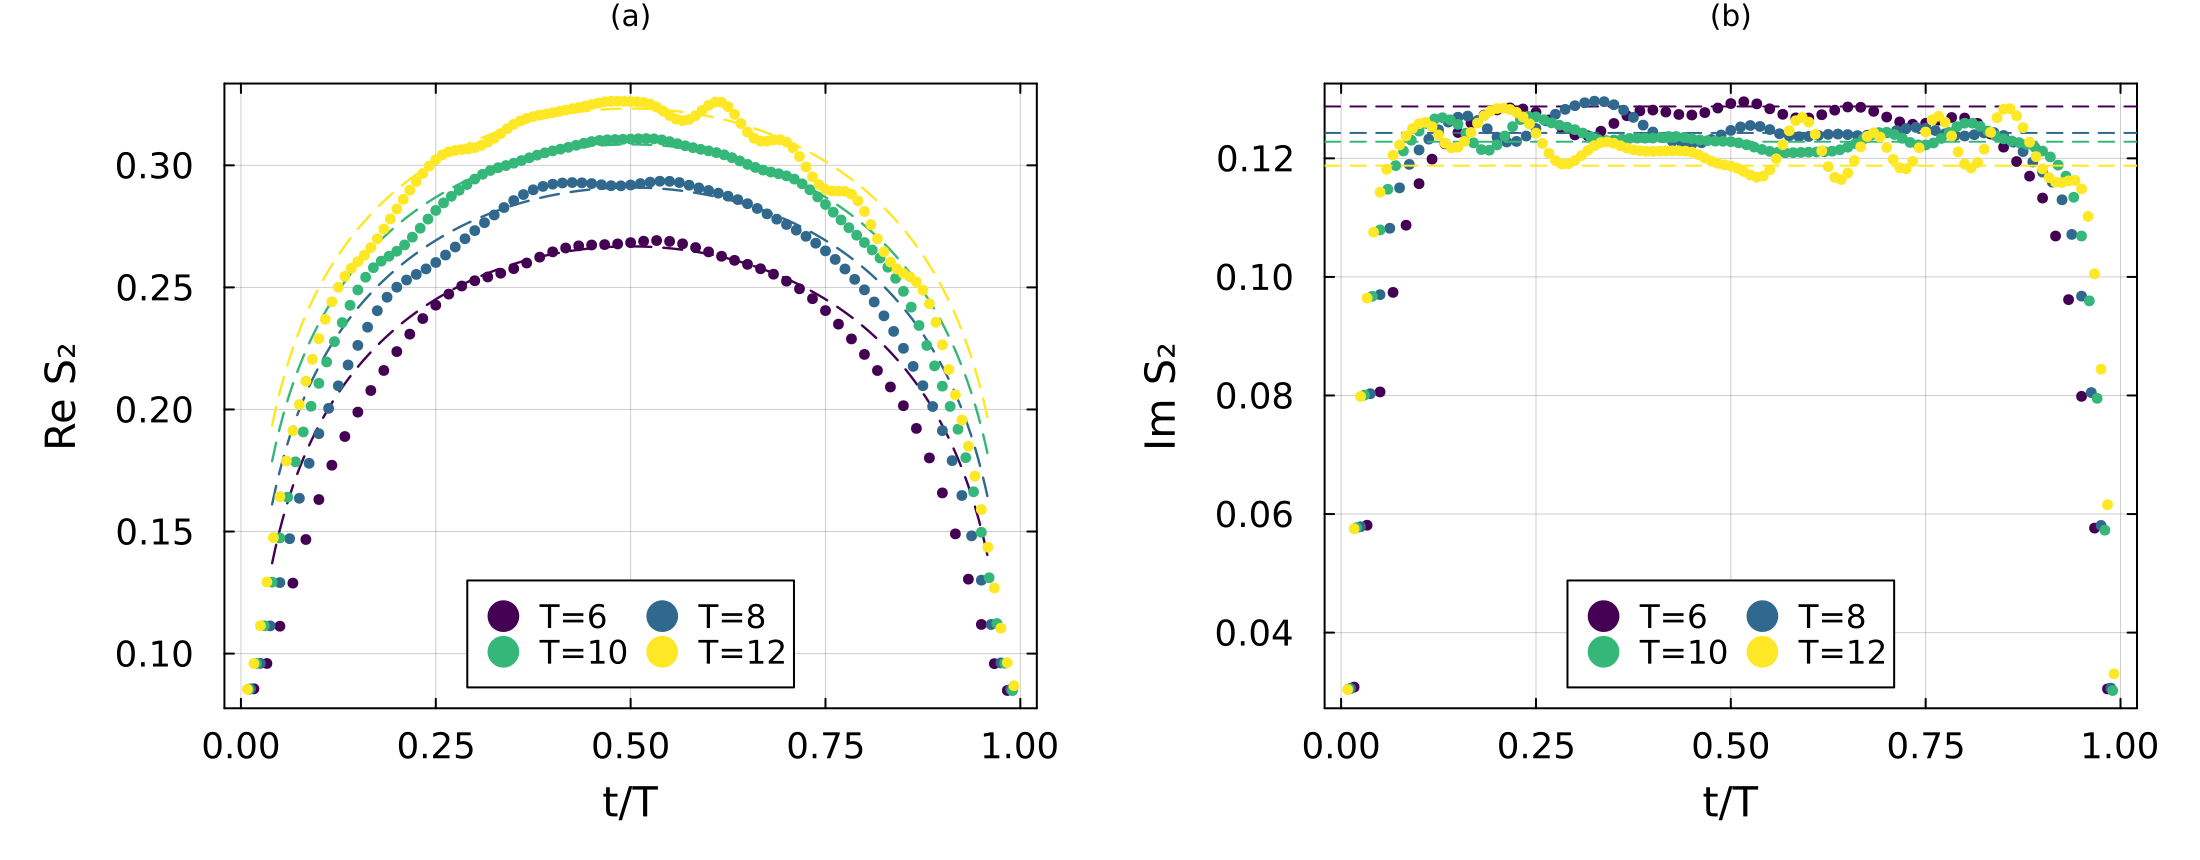

In [2]:
p0_T = sort([k[2] for k in keys(M8) if k[1] == 0.0])
Tshow = [T for T in p0_T if iseven(Int(T)) && T >= 6]
pal = cgrad(:viridis, length(Tshow), categorical=true)

# panel a: Re S2 against t/T, with the c=1/2 chord curve at a fitted offset
pa = plot(xlabel="t/T", ylabel="Re S₂", legend=:bottom, legendcolumns=2, title="(a)", titlefontsize=10)
for (i, T) in enumerate(Tshow)
    s2 = real.(M8[(0.0, T)].s2_phys)
    n = length(s2)
    ts = range(T/(n+1), T - T/(n+1), length=n)
    bulk = (n÷4):(3n÷4)
    s0 = mean(s2[bulk] .- (0.5/8) .* W.(ts[bulk], T))
    scatter!(pa, ts ./ T, s2, color=pal[i], ms=3, msw=0, label="T=$(Int(T))")
    tt = range(0.04, 0.96, length=200)
    plot!(pa, tt, (0.5/8) .* W.(tt .* T, T) .+ s0, color=pal[i], lw=1.2, ls=:dash, label="")
end

# panel b: Im S2 against t/T, one colour per T, with the measured plateau of each
pb = plot(xlabel="t/T", ylabel="Im S₂", legend=:bottom, legendcolumns=2, title="(b)", titlefontsize=10)
plateau(T) = mean(imag.(M8[(0.0, T)].s2_phys)[max(1, length(M8[(0.0,T)].s2_phys)÷2 - 1):(length(M8[(0.0,T)].s2_phys)÷2 + 2)])
for (i, T) in enumerate(Tshow)
    s2 = imag.(M8[(0.0, T)].s2_phys)
    n = length(s2)
    scatter!(pb, range(1/(n+1), 1 - 1/(n+1), length=n), s2, color=pal[i], ms=3, msw=0, label="T=$(Int(T))")
    hline!(pb, [plateau(T)], color=pal[i], lw=1.0, ls=:dash, label="")
end

fig = plot(pa, pb, layout=(1,2), size=(1100, 430), margin=6Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_domes_p0.png")
for T in Tshow
    @printf("T=%2d  plateau = %.4f\n", Int(T), plateau(T))
end
@printf("asymptotic πc/16 at c=1/2 = %.4f\n", pi/32)
fig

## The entropy route under frustration

The dome survives only inside a window that shrinks with p. The cell fits the real part against the chord variable inside each clean window, pools all T of the window in one fit, and reads the calibrated central charge as c = (1/2) x slope(p)/slope(0). The windows come from the two-part dome test of NB9 (single hump and no selector repair).

p      slope      c_raw=8s    c_cal=0.5*s/s0   pooled pts


0.0   0.08303    0.664       0.500            365
0.1   0.08729    0.698       0.526            198


0.3   0.30484    2.439       1.836            26
0.5   0.99907    7.993       6.017            11


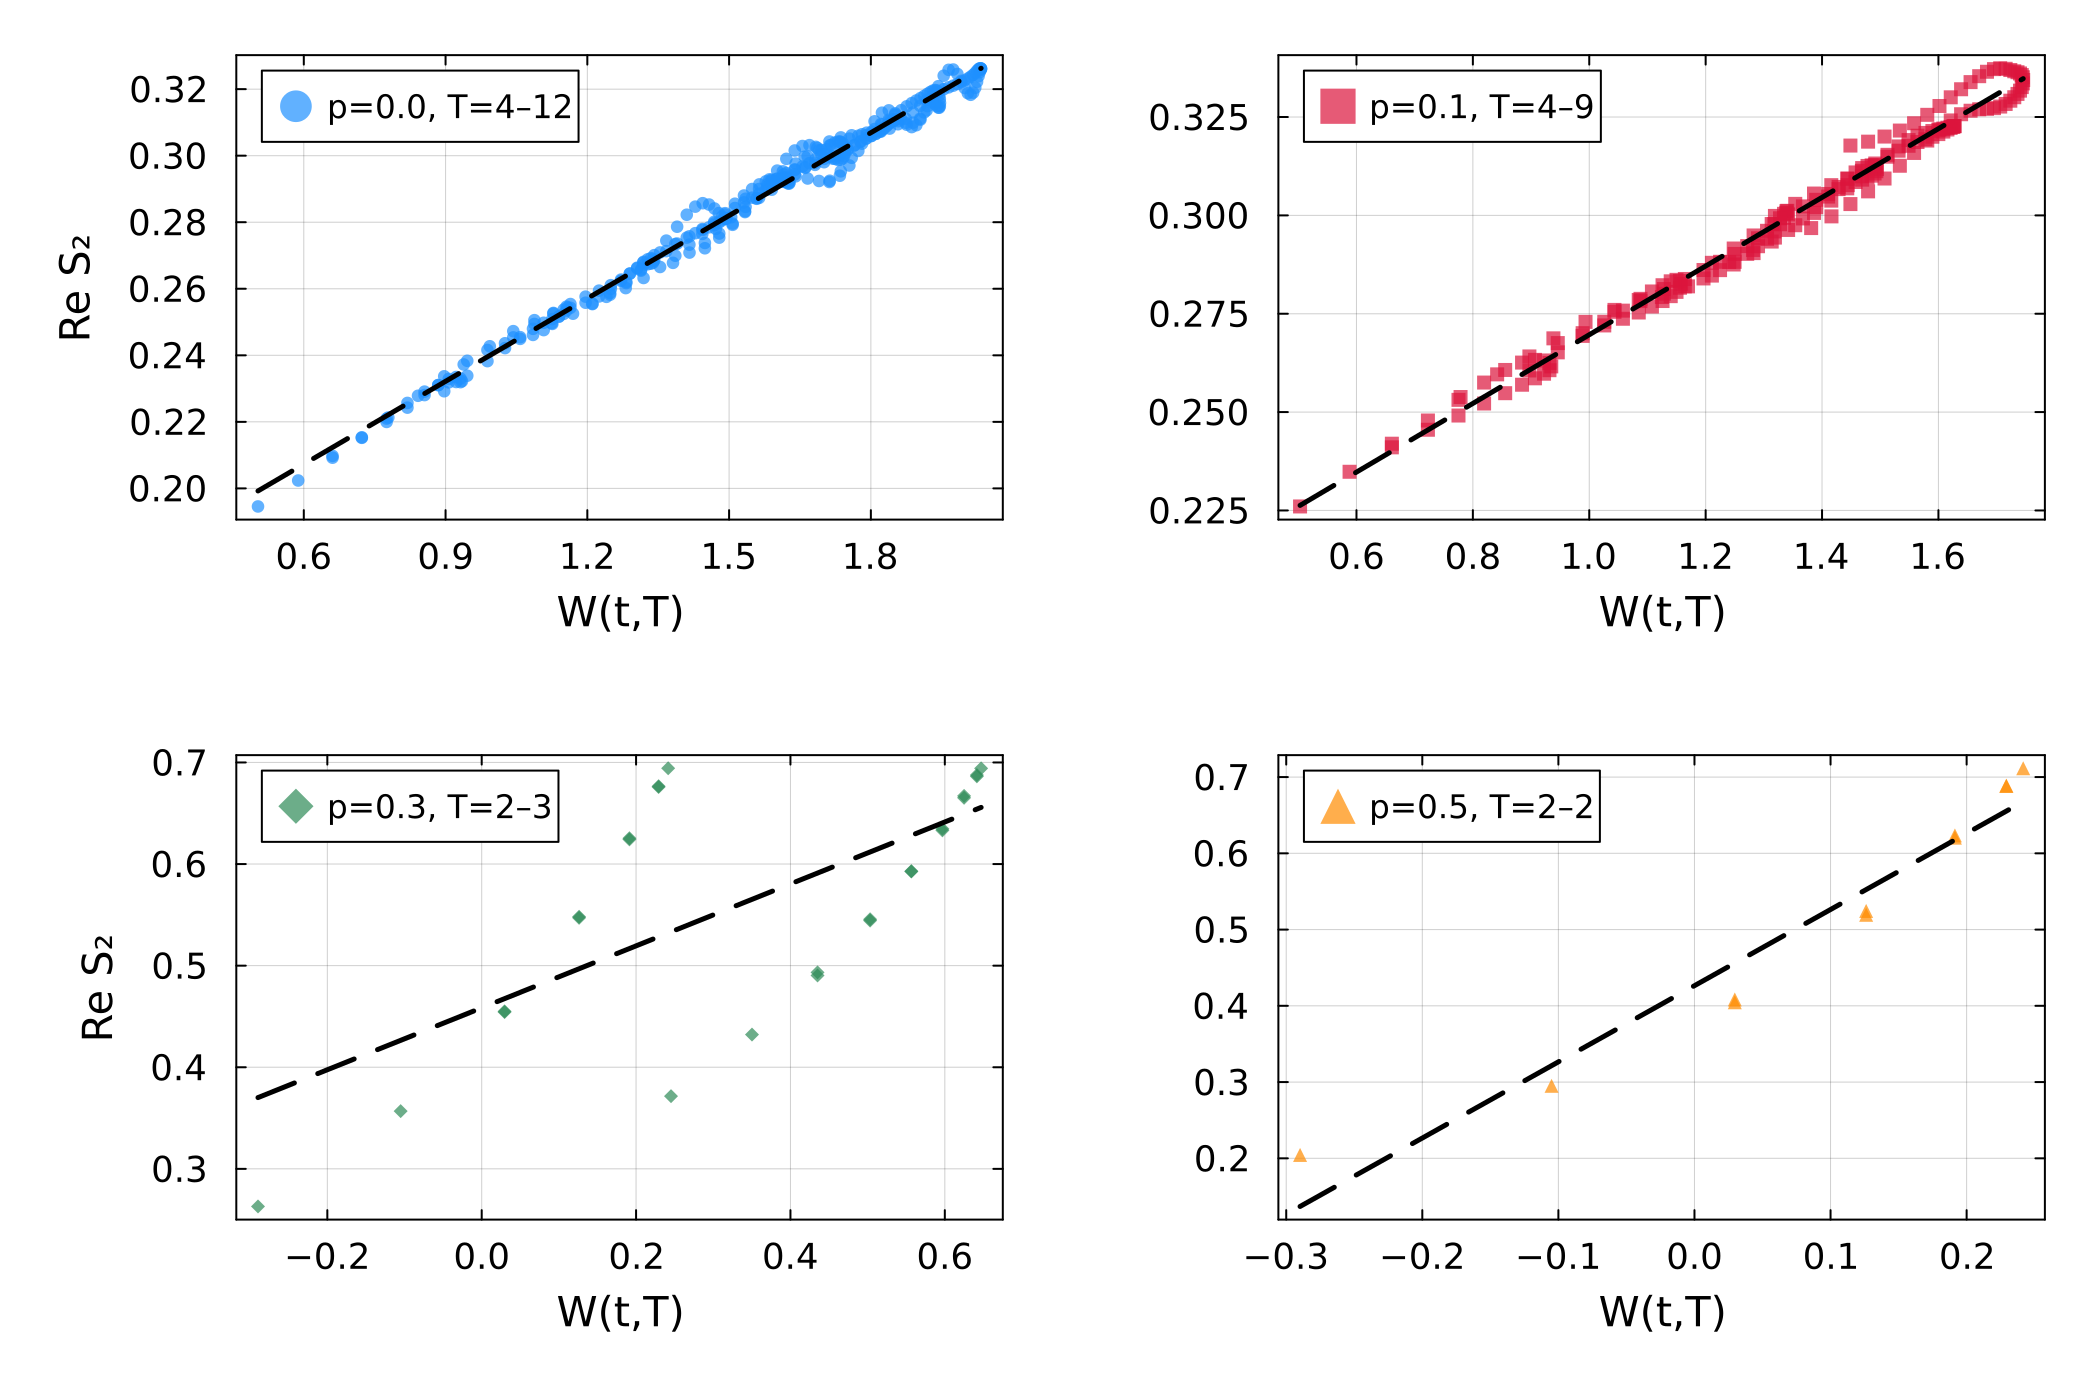

In [3]:
# clean windows established in NB9; p=0 has no wall
clean_win = Dict(0.0 => (4.0, 12.0), 0.1 => (4.0, 9.0), 0.3 => (2.0, 3.0), 0.5 => (2.0, 2.0))
src_p = Dict(0.0 => () -> Dict(T => M8[(0.0,T)].s2_phys for T in p0_T),
             0.1 => () -> Dict(k[2] => M8[k].s2_phys for k in keys(M8) if k[1] == 0.1),
             0.3 => () -> Dict(T => e.s2_base for (T, e) in load_arm("sweep_rtm_p0.3.jld2", "rtm_p0.3")),
             0.5 => () -> Dict(T => e.s2_base for (T, e) in load_arm("sweep_rtm_p0.5.jld2", "rtm_p0.5")))

lin(x, q) = q[1] .* x .+ q[2]
slopes = Dict{Float64,Float64}(); icepts = Dict{Float64,Float64}(); npts = Dict{Float64,Int}()
panels = []
for p in (0.0, 0.1, 0.3, 0.5)
    prof = src_p[p](); lo, hi = clean_win[p]
    xs = Float64[]; ys = Float64[]
    for T in sort(collect(keys(prof)))
        s2 = prof[T]
        lo <= T <= hi || continue
        s2r = real.(s2); n = length(s2r)
        ts = range(T/(n+1), T - T/(n+1), length=n)
        bulk = (n÷4):(3n÷4)
        append!(xs, W.(ts[bulk], T)); append!(ys, s2r[bulk])
    end
    fit = curve_fit(lin, xs, ys, [0.06, 0.5])
    slopes[p] = fit.param[1]; icepts[p] = fit.param[2]; npts[p] = length(xs)
    pan = plot(xlabel="W(t,T)", ylabel=p in (0.0, 0.3) ? "Re S₂" : "", legend=:topleft)
    scatter!(pan, xs, ys, color=P_COLOR[p], marker=P_MARKER[p], ms=3.5, msw=0, alpha=0.7,
             label=@sprintf("p=%.1f, T=%g–%g", p, lo, hi))
    wr = range(minimum(xs), maximum(xs), length=50)
    plot!(pan, wr, lin(wr, fit.param), color=:black, ls=:dash, label="")
    push!(panels, pan)
end
fig = plot(panels..., layout=(2,2), size=(1050, 700), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_chordfits_p.png")
println("p      slope      c_raw=8s    c_cal=0.5*s/s0   pooled pts")
for p in (0.0, 0.1, 0.3, 0.5)
    @printf("%.1f   %.5f    %.3f       %.3f            %d\n", p, slopes[p], 8slopes[p], 0.5*slopes[p]/slopes[0.0], npts[p])
end
fig

## Where the eigenvector route ends

Prediction: the route breaks where the transfer matrix nears an exceptional point, diagnosed by the phase rigidity of the dominant pair collapsing. Panel a shows the rigidity against T for every p with eigenvector data. Panel b shows the p=0.1 chord scatter with the past-wall points included: the T > 9 points leave the line the clean window defines.

p=0.0  r: 0.29 at T=2  ->  0.00013 at T=14
p=0.1  r: 0.085 at T=2  ->  5.3e-06 at T=10


p=0.3  r: 0.051 at T=2  ->  1.4e-10 at T=14
p=0.5  r: 0.014 at T=2  ->  7.3e-08 at T=7


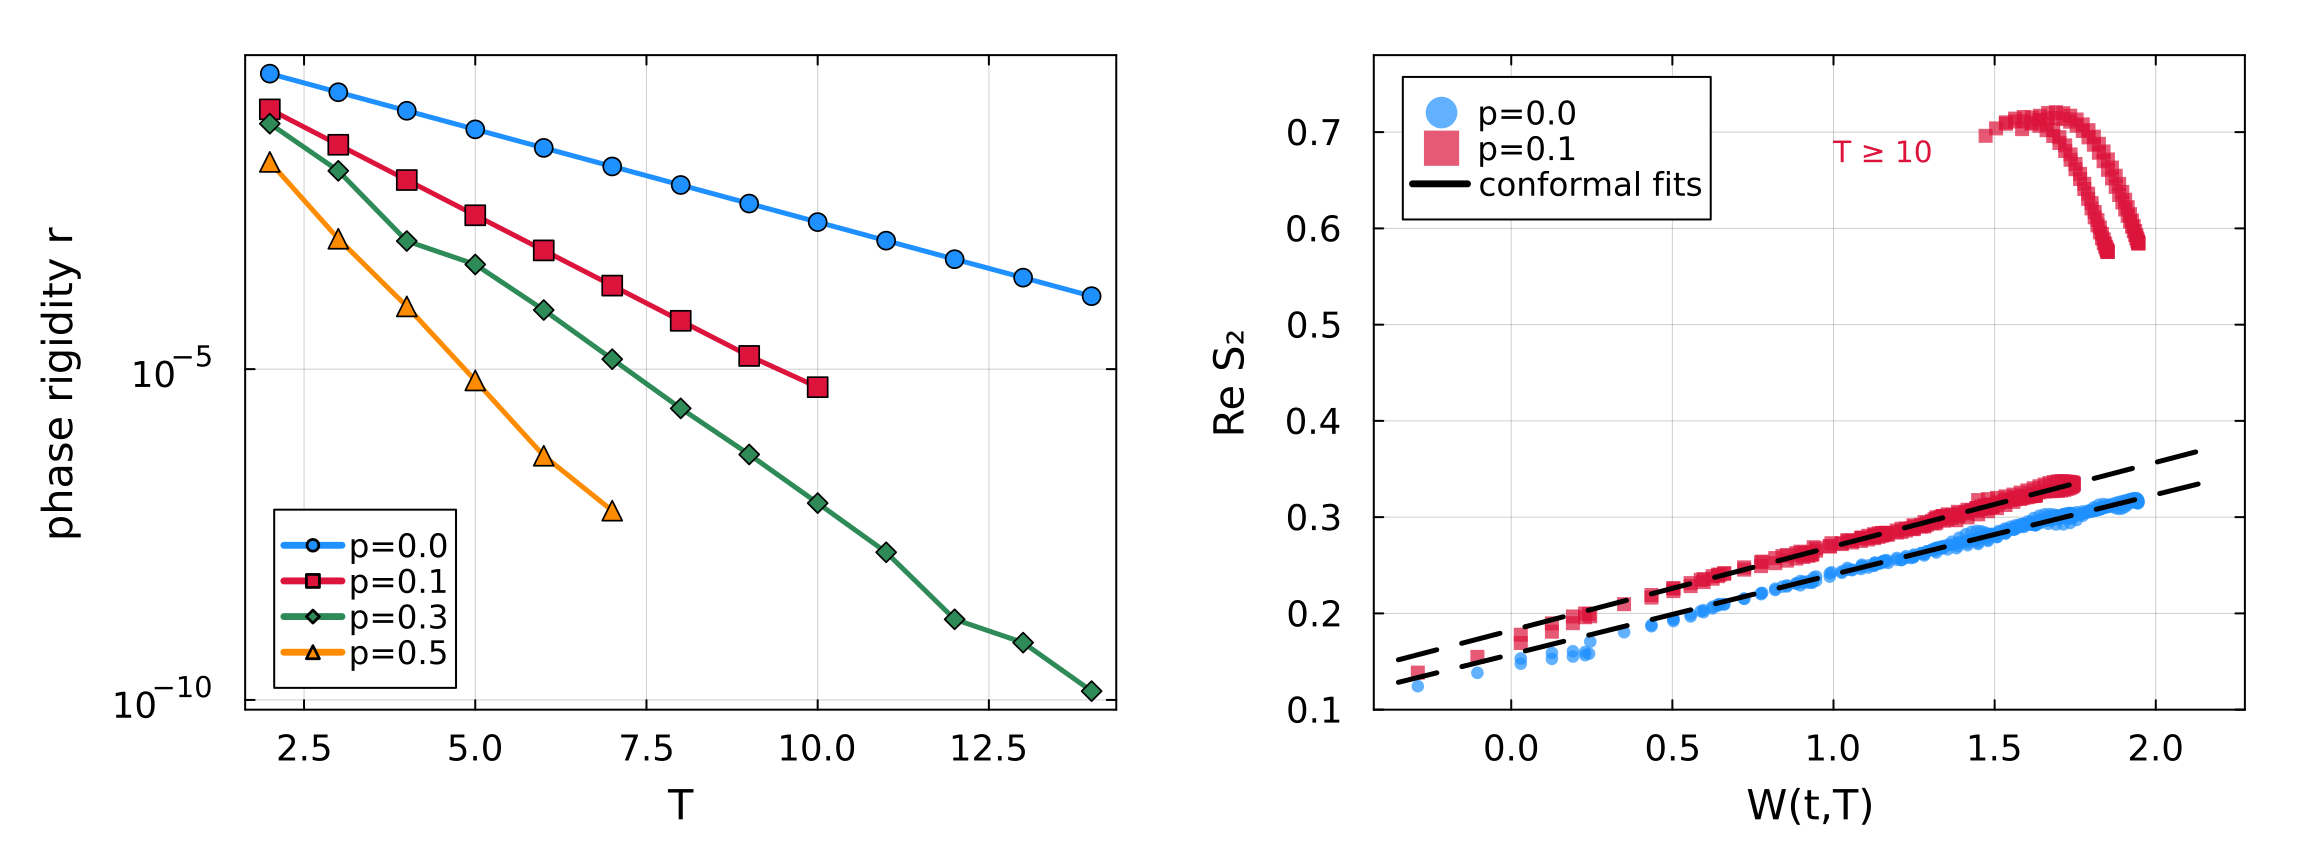

In [4]:
# panel a: rigidity of the physical pair vs T, per p
pa = plot(xlabel="T", ylabel="phase rigidity r", yscale=:log10, legend=:bottomleft)
rig_src = Dict(
    0.1 => Dict(T => e.rigidity[e.i0] for (T, e) in load("../results/data/nb13_eigvec_ladder.jld2", "done") if !isempty(e.rigidity)),
    0.3 => Dict(T => e.rigidity[e.i0] for (T, e) in load_arm("sweep_rtm_p0.3.jld2", "rtm_p0.3") if !isempty(e.rigidity)),
    0.5 => Dict(T => e.rigidity[e.i0] for (T, e) in load_arm("sweep_rtm_p0.5.jld2", "rtm_p0.5") if !isempty(e.rigidity)))
arm0 = load_arm("sweep_rtm_p0.0.jld2", "rtm_p0.0")
rig_src[0.0] = Dict(T => e.rigidity[e.i0] for (T, e) in arm0 if !isempty(e.rigidity))
for p in (0.0, 0.1, 0.3, 0.5)
    d = rig_src[p]; Ts = sort(collect(keys(d)))
    isempty(Ts) && continue
    plot!(pa, Ts, [d[T] for T in Ts], color=P_COLOR[p], marker=P_MARKER[p], ms=5, label="p=$(p)")
end

# panel b: chord scatter. Same colour and marker throughout each coupling — past the wall the
# points simply leave the line, which is the whole message.
pb = plot(xlabel="W(t,T)", ylabel="Re S₂", legend=:topleft, ylims=(0.1, 0.78))
for p in (0.0, 0.1)
    first = true
    for T in sort([k[2] for k in keys(M8) if k[1] == p && k[2] <= 11.0])
        s2 = real.(M8[(p, T)].s2_phys); n = length(s2)
        ts = range(T/(n+1), T - T/(n+1), length=n); bulk = (n÷4):(3n÷4)
        scatter!(pb, W.(ts[bulk], T), s2[bulk], color=P_COLOR[p], marker=P_MARKER[p],
                 ms=3.5, msw=0, alpha=0.7, label=first ? "p=$(p)" : "")
        first = false
    end
end
# fit lines added after both scatters so their legend entry comes last
for p in (0.0, 0.1)
    wr = range(-0.35, 2.2, length=40)
    plot!(pb, wr, slopes[p] .* wr .+ icepts[p], color=:black, ls=:dash,
          label=p == 0.5 ? "" : (p == 0.1 ? "conformal fits" : ""))
end
annotate!(pb, 1.15, 0.68, text("T ≥ 10", 10, P_COLOR[0.1]))

fig = plot(pa, pb, layout=(1,2), size=(1150, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_wall.png")
for p in (0.0, 0.1, 0.3, 0.5)
    d = rig_src[p]; Ts = sort(collect(keys(d)))
    isempty(Ts) || @printf("p=%.1f  r: %.2g at T=%g  ->  %.2g at T=%g\n", p, d[Ts[1]], Ts[1], d[Ts[end]], Ts[end])
end
fig

## Locating the wall on the entropy profile

A conformal profile is linear in W with slope c/8. The cell below plots the p=0.1 profiles at T=9 and T=10 against that line, with cuts from the two halves of the strip marked separately.

At T=9 the profile follows the line; at T=10 it does not. Past that step the power method has converged to something other than the physical eigenvectors, so the shape of the T=10 curve is an artefact and only the time of the departure is used.

T=9  peak Re S2 = 0.337  n_maxima = 1  max deviation from the c=1/2 line = 0.056
T=10  peak Re S2 = 0.716  n_maxima = 2  max deviation from the c=1/2 line = 0.422


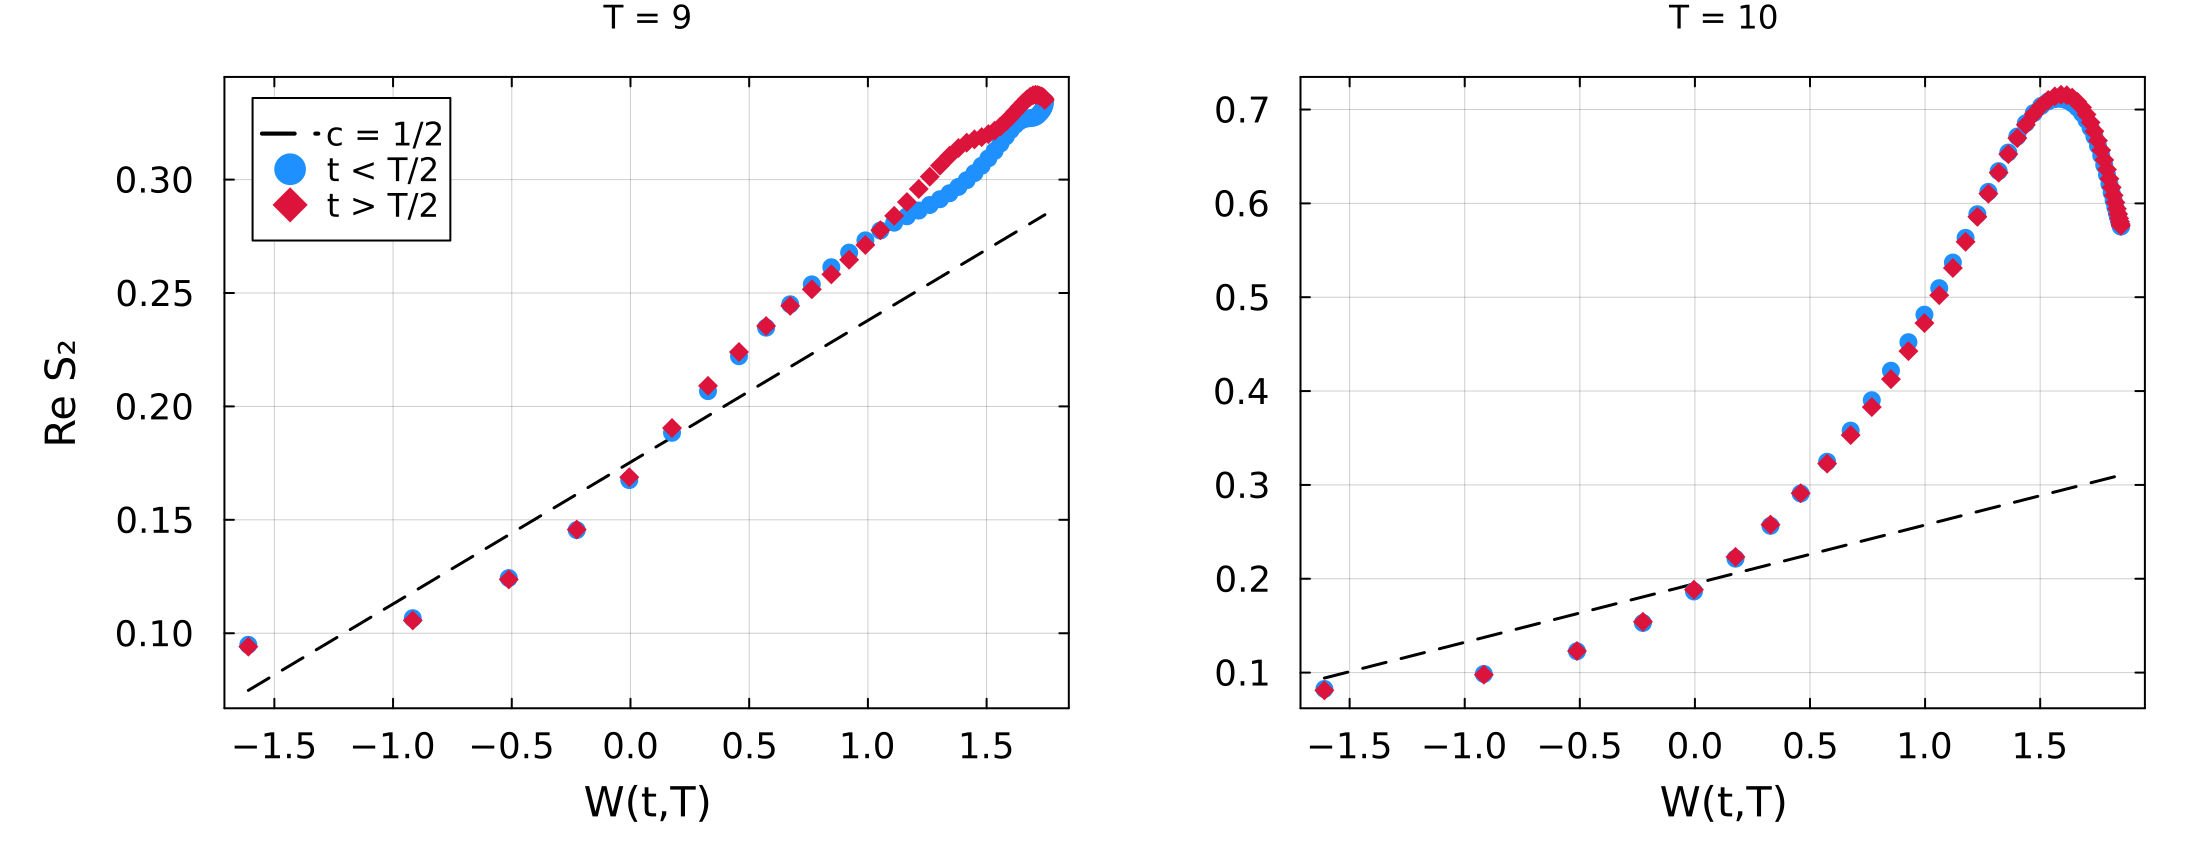

In [5]:
panels = []
for T in (9.0, 10.0)
    s2 = real.(M8[(0.1, T)].s2_phys)
    n = length(s2)
    ts = range(T/(n+1), T - T/(n+1), length=n)
    Ws = W.(ts, T)
    first_half = [i for i in 1:n if ts[i] <= T/2]
    second_half = [i for i in 1:n if ts[i] > T/2]

    # conformal line: slope c/8 at c=1/2, offset fixed on the small-W points
    small_W = [i for i in 1:n if Ws[i] < 0.5]
    s0 = mean(s2[small_W] .- (0.5/8) .* Ws[small_W])
    Wr = range(minimum(Ws), maximum(Ws), length=50)

    pan = plot(xlabel="W(t,T)", ylabel=(T == 9.0 ? "Re S₂" : ""), legend=(T == 9.0 ? :topleft : false),
               title="T = $(Int(T))", titlefontsize=11)
    plot!(pan, Wr, (0.5/8) .* Wr .+ s0, color=:black, ls=:dash, lw=1.5, label="c = 1/2")
    scatter!(pan, Ws[first_half], s2[first_half], color=:dodgerblue, marker=:circle, ms=5, msw=0, label="t < T/2")
    scatter!(pan, Ws[second_half], s2[second_half], color=:crimson, marker=:diamond, ms=5, msw=0, label="t > T/2")
    push!(panels, pan)

    deviation = maximum(abs.(s2 .- ((0.5/8) .* Ws .+ s0)))
    n_maxima = count(i -> 1 < i < n && s2[i] > s2[i-1] && s2[i] > s2[i+1], 1:n)
    @printf("T=%g  peak Re S2 = %.3f  n_maxima = %d  max deviation from the c=1/2 line = %.3f\n",
            T, maximum(s2), n_maxima, deviation)
end
fig = plot(panels..., layout=(1,2), size=(1100, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_broken_dome.png")
fig

## The spectral route at the integrable point

The eigenvalue-only ladder reaches T=20 at p=0. Panel a traces mu0 in the complex plane (dual unitarity: constant radius, winding phase). Panel b shows the corrected Eq.(3) fit of the unwrapped phase. The boundary exponent panel compares the free and fixed boundary states over the same displayed window.

p=0 eq3 over T=2–20: C=-0.0318  c=0.480


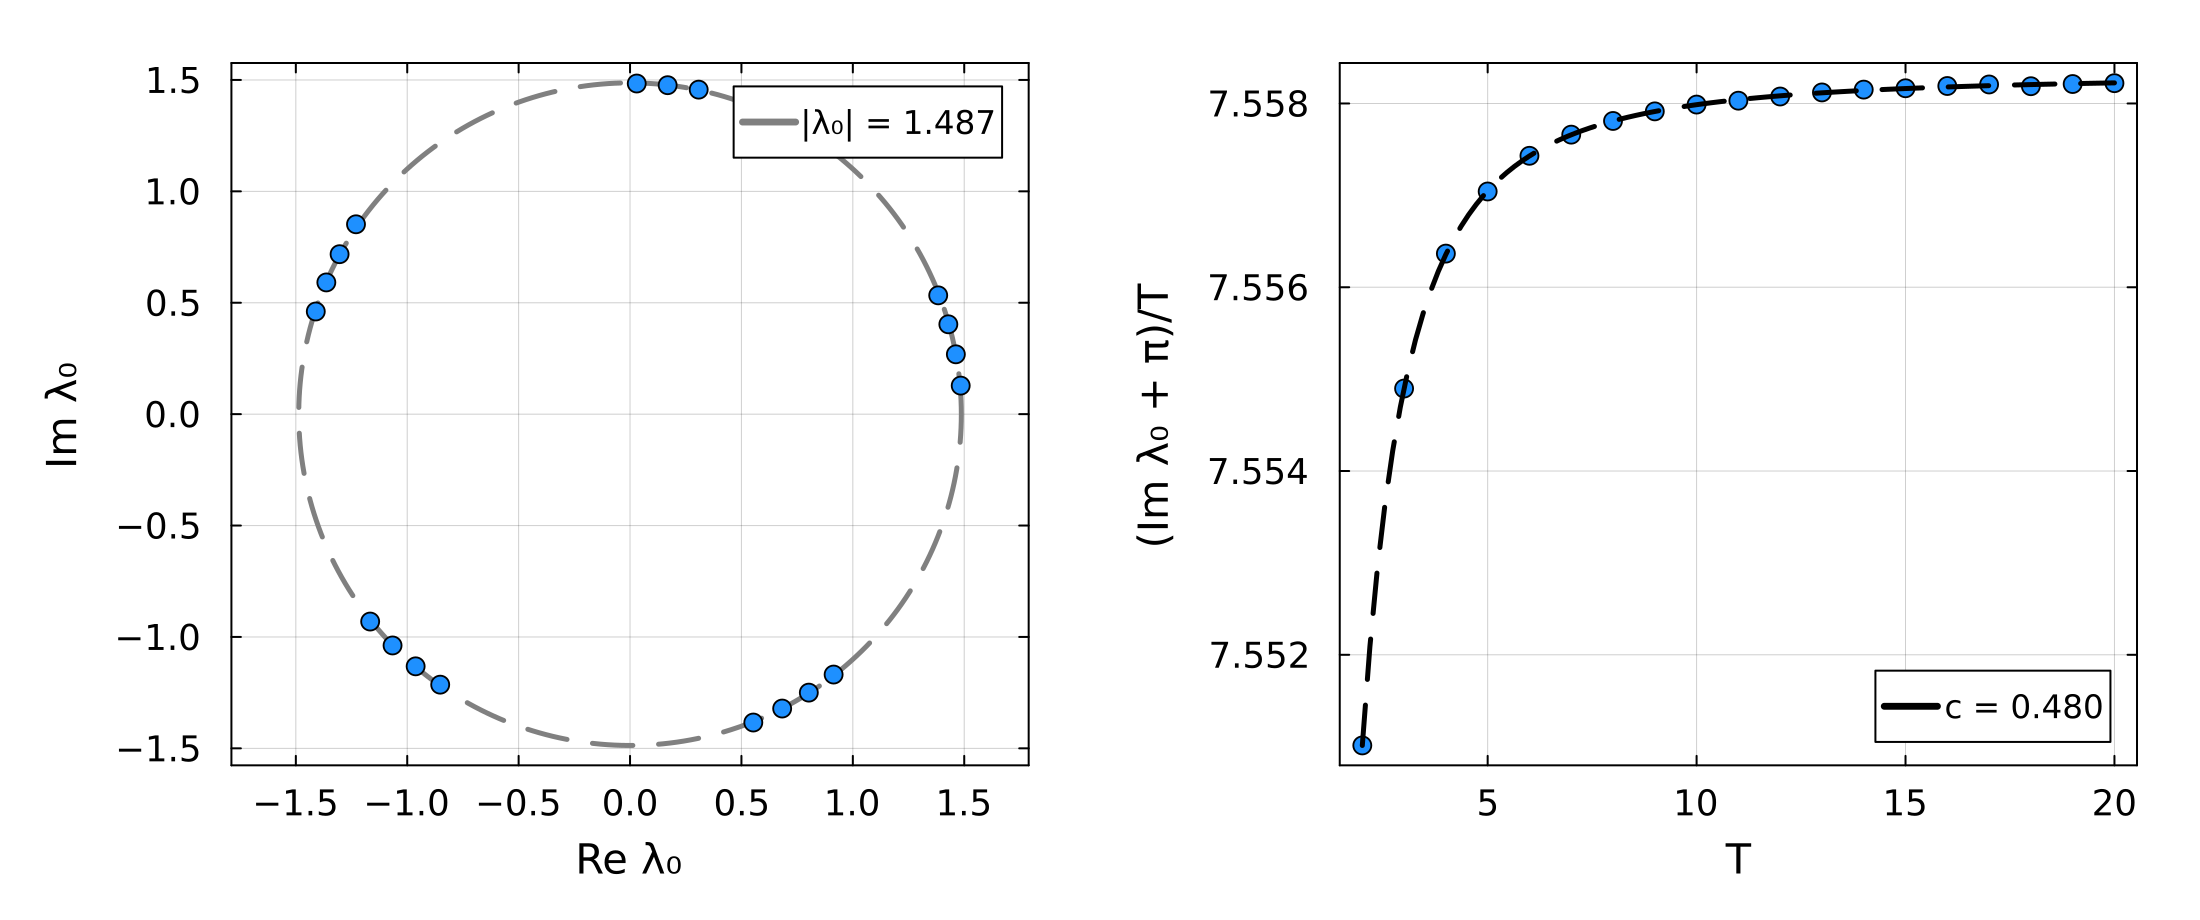

In [6]:
eig0 = load_arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0")
ch0, Phi0, ok0, cst0 = phase_chain(eig0)
fb = findfirst(T -> cst0[T] >= 0.02, ok0); Ts0 = fb === nothing ? ok0 : ok0[1:fb-1]
th0 = [eig0[T].theta[ch0[T]] for T in Ts0]

# panel a: complex-plane circle
pa = plot(xlabel="Re λ₀", ylabel="Im λ₀", aspect_ratio=:equal, legend=:topright)
r0 = mean(abs.(th0))
phis = range(0, 2pi, length=300)
plot!(pa, r0 .* cos.(phis), r0 .* sin.(phis), color=:gray, ls=:dash, label=@sprintf("|λ₀| = %.3f", r0))
scatter!(pa, real.(th0), imag.(th0), color=P_COLOR[0.0], marker=P_MARKER[0.0], ms=5, label="")

# panel b: Eq.(3) on the unwrapped phase, B pinned at -π
phase_unwrapped = [Phi0[T] for T in Ts0]
eq3f(T, q) = q[1] .* T .+ q[2] .+ q[3] ./ T .+ q[4] ./ T.^3
ff0 = curve_fit(eq3f, Ts0, phase_unwrapped, [1.0, -3.0, -0.2, 0.0])
phase_unwrapped = phase_unwrapped .- 2pi * round((ff0.param[2] + pi) / (2pi))
y = (phase_unwrapped .+ pi) ./ Ts0
eq3(T, q) = q[1] .+ q[2] ./ T.^2 .+ q[3] ./ T.^4
fit0 = curve_fit(eq3, Ts0, y, [0.5, -0.2, 0.0])
c_eq3_p0 = 24 * V[0.0] * abs(fit0.param[2]) / pi
pb = plot(xlabel="T", ylabel="(Im λ₀ + π)/T", legend=:bottomright)
scatter!(pb, Ts0, y, color=P_COLOR[0.0], marker=P_MARKER[0.0], ms=5, label="")
Tr = range(minimum(Ts0), maximum(Ts0), length=100)
plot!(pb, Tr, eq3(Tr, fit0.param), color=:black, ls=:dash, label=@sprintf("c = %.3f", c_eq3_p0))

fig = plot(pa, pb, layout=(1,2), size=(1100, 460), margin=6Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_spectral_p0.png")
@printf("p=0 eq3 over T=%g–%g: C=%.4f  c=%.3f\n", Ts0[1], Ts0[end], fit0.param[2], c_eq3_p0)
fig

free  |X+⟩  T=2–9  n=8  x1=0.4909  (per-time x from 0.447 to 0.498)
fixed |Up⟩  T=2–9  n=8  x1=1.9736  (per-time x from 1.798 to 1.955)


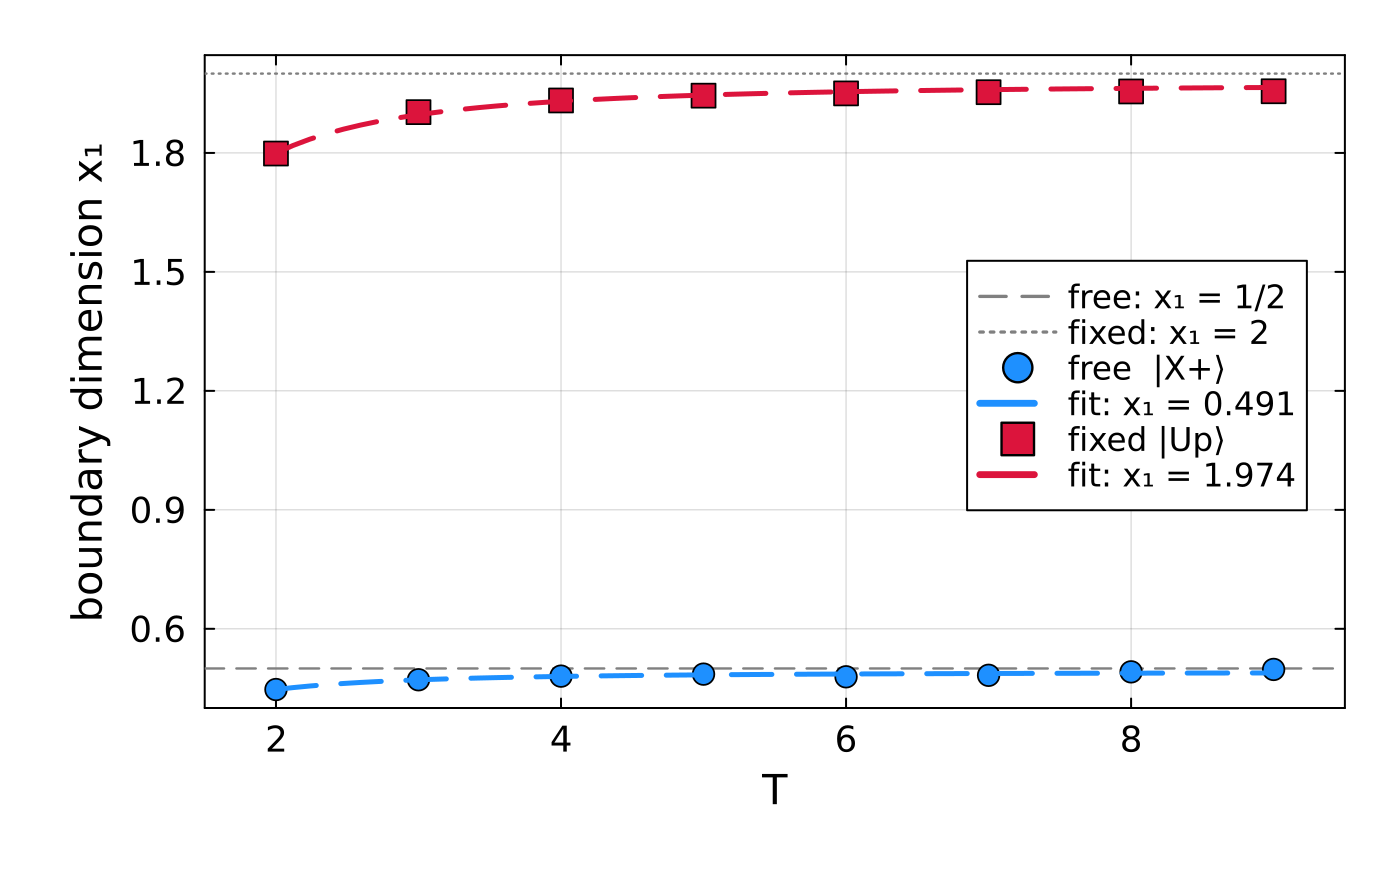

In [7]:
free_d = load_arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0")
fixed_raw = load("../results/data/nb7_alcaraz_fixedbc.jld2", "done")
fixed_d = Dict(k[2] => v for (k, v) in fixed_raw if k[1] == 0.0 && !haskey(v, :error))

x1_model(T, q) = q[1] ./ T .+ q[2] ./ T.^3

function lam1_gap(e)   # signed phase gap to the block member closest in phase to λ0
    th = e.theta; i0 = e.i0
    best = 0.0; bg = Inf
    for (i, t) in enumerate(th)
        i == i0 && continue
        g = dphw(ph(t), ph(th[i0]))
        abs(g) < bg && (bg = abs(g); best = g)
    end
    return best
end

Tlo = 2.0
Thi = min(maximum(keys(free_d)), maximum(keys(fixed_d)))

fig = plot(xlabel="T", ylabel="boundary dimension x₁", legend=:right, xlims=(Tlo - 0.5, Thi + 0.5))
hline!(fig, [0.5], color=:gray, ls=:dash, lw=1.2, label="free: x₁ = 1/2")
hline!(fig, [2.0], color=:gray, ls=:dot, lw=1.2, label="fixed: x₁ = 2")

for (name, dat, col, mk) in (("free  |X+⟩", free_d, P_COLOR[0.0], :circle),
                             ("fixed |Up⟩", fixed_d, P_COLOR[0.1], :square))
    Ts = [T for T in sort(collect(keys(dat))) if T <= Thi]
    gaps = [lam1_gap(dat[T]) for T in Ts]
    xs = [V[0.0] * T * g / pi for (T, g) in zip(Ts, gaps)]
    scatter!(fig, Ts, xs, color=col, marker=mk, ms=6, label=name)

    sel = [Tlo <= T <= Thi for T in Ts]
    fitx = curve_fit(x1_model, Ts[sel], gaps[sel], [1.0, 0.0])
    x1 = V[0.0] * fitx.param[1] / pi
    Tr = range(Tlo, Thi, length=60)
    plot!(fig, Tr, V[0.0] .* Tr .* x1_model(Tr, fitx.param) ./ pi, color=col, ls=:dash,
          label=@sprintf("fit: x₁ = %.3f", x1))
    @printf("%s  T=%g–%g  n=%d  x1=%.4f  (per-time x from %.3f to %.3f)\n",
            name, Tlo, Thi, count(sel), x1, minimum(xs), maximum(xs))
end
plot!(fig, size=(700, 440))
savefig(fig, "../results/imgs/res_x1_p0.png")
fig

## The spectral route under frustration

The corrected Eq.(3) fit on the phase-tracked physical branch, per p. At p=0.1 the branch is trackable to T=11; at p=0.3 and 0.5 the phase advance per rung is too fast for the T-spacing of the ladder and the branch is lost after a few rungs, so those arms are excluded from the fit. The cell also compares the B-free and B-pinned fits to test whether the long windows lift the B-C trade-off.

B–C degeneracy test (B free vs pinned):


p=0.0  T≤ 9.0:  B_free=-3.142 (−π=-3.142)  C=-0.03171  ->  c=0.479
p=0.0  T≤11.0:  B_free=-3.141 (−π=-3.142)  C=-0.03305  ->  c=0.499


p=0.0  T≤20.0:  B_free=-3.141 (−π=-3.142)  C=-0.03237  ->  c=0.489
p=0.1  T≤ 9.0:  B_free=-3.144 (−π=-3.142)  C=-0.02698  ->  c=0.536
p=0.1  T≤11.0:  B_free=-3.148 (−π=-3.142)  C=-0.01602  ->  c=0.318
p=0.1  T≤20.0:  B_free=-3.148 (−π=-3.142)  C=-0.01602  ->  c=0.318


matched window T<= 9.0:  absolute c(0)=0.479  c(0.1)=0.536   ratio-with-v=0.560
matched window T<=11.0:  absolute c(0)=0.499  c(0.1)=0.318   ratio-with-v=0.319


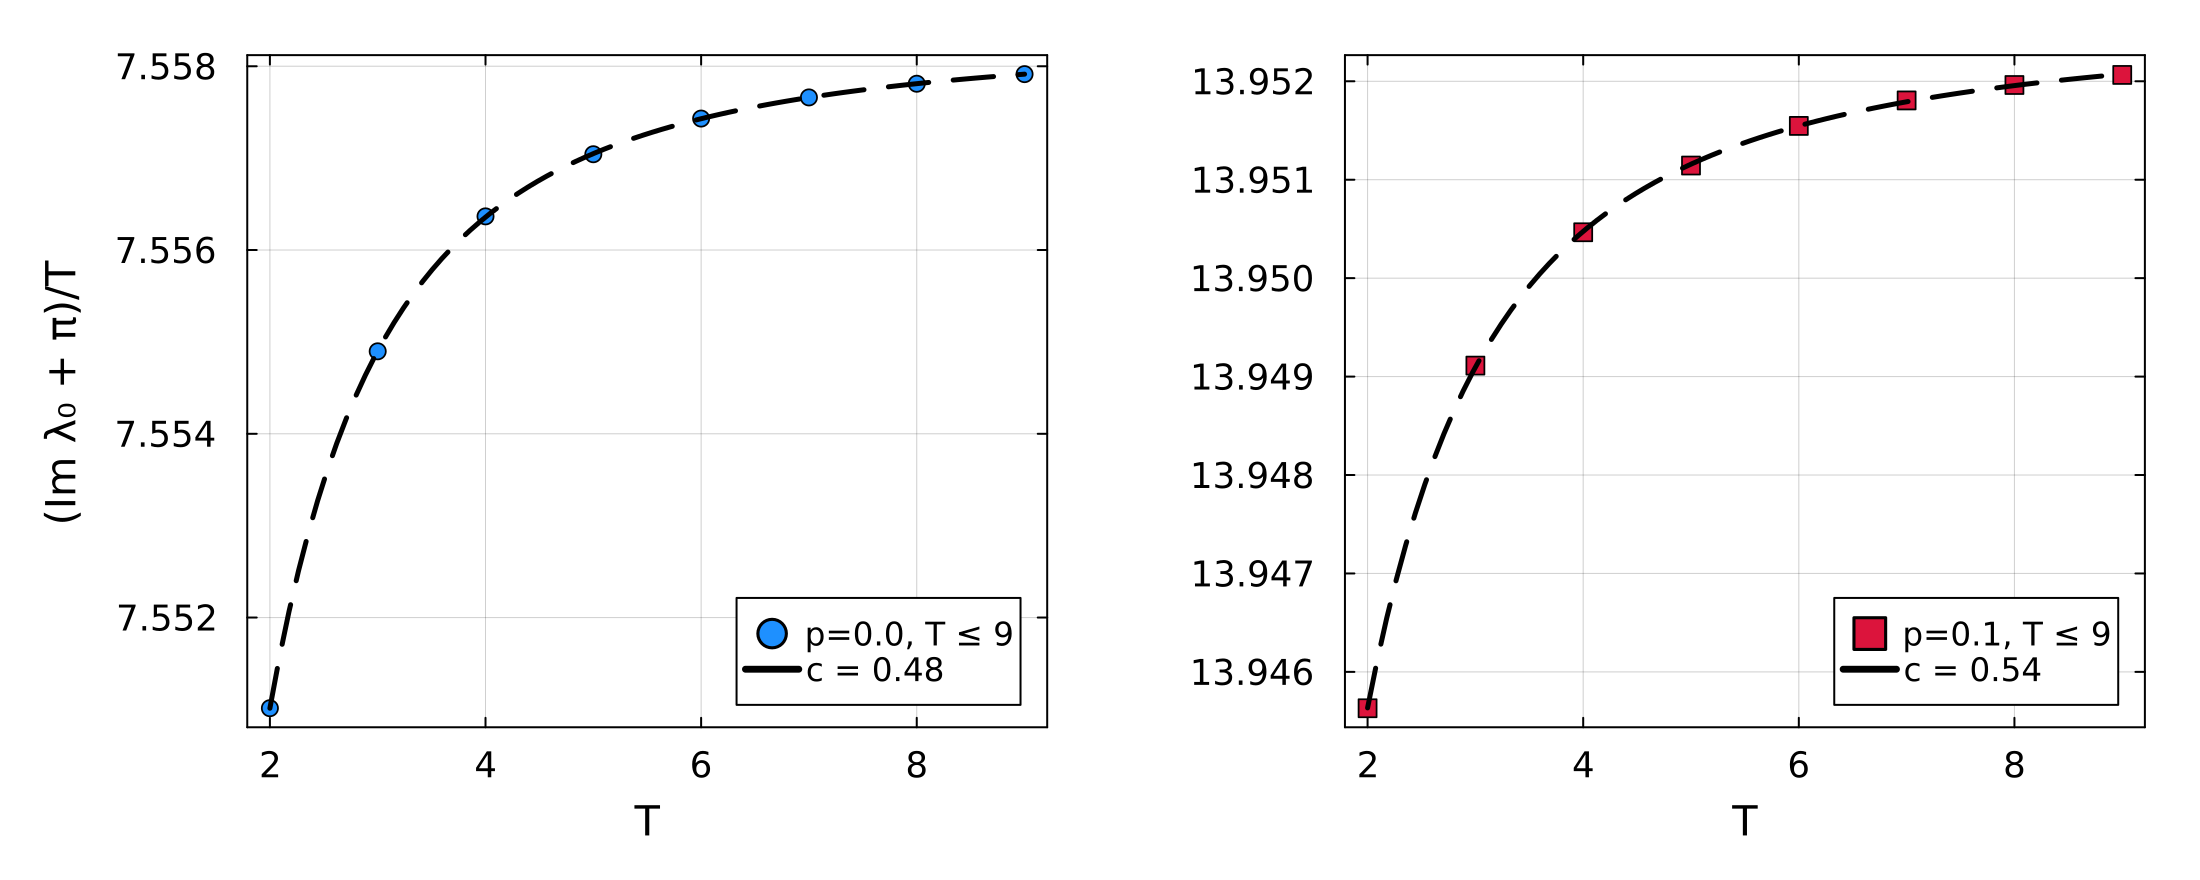

In [8]:
arms = Dict(p => load_arm("sweep_rtm_eigs_p$(p).jld2", "rtm_eigs_p$(p)") for p in (0.0, 0.1, 0.3, 0.5))
eq3f(T, q) = q[1] .* T .+ q[2] .+ q[3] ./ T .+ q[4] ./ T.^3   # B free
eq3p(T, q) = q[1] .* T .- pi .+ q[2] ./ T .+ q[3] ./ T.^3     # B pinned at -π
Cs = Dict{Float64,Float64}()
panels = []
for p in (0.0, 0.1)
    arm = arms[p]; chn, Phi, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.02, okT); Ts = fb === nothing ? okT : okT[1:fb-1]
    phw = [Phi[T] for T in Ts]
    # normalize the global 2π sheet so the branch constant sits at -π
    ff0 = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    phw = phw .- 2pi * round((ff0.param[2] + pi) / (2pi))
    Ts = [T for T in Ts if T <= 9.0]           # window where the free fit still locks B onto -π
    phw = phw[1:length(Ts)]
    fitp = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    Cs[p] = fitp.param[3]
    pan = plot(xlabel="T", ylabel=p in (0.0, 0.3) ? "(Im λ₀ + π)/T" : "", legend=:bottomright)
    scatter!(pan, Ts, (phw .+ pi) ./ Ts, color=P_COLOR[p], marker=P_MARKER[p], ms=4.5,
             label=@sprintf("p=%.1f, T ≤ %g", p, Ts[end]))
    Tr = range(Ts[1], Ts[end], length=80)
    plot!(pan, Tr, (eq3f(Tr, fitp.param) .+ pi) ./ Tr, color=:black, ls=:dash,
          label=@sprintf("c = %.2f", 24V[p]*abs(fitp.param[3])/pi))
    push!(panels, pan)
end
fig = plot(panels..., layout=(1,2), size=(1100, 440), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_eq3_p.png")

println("B–C degeneracy test (B free vs pinned):")
for p in (0.0, 0.1)
    arm = arms[p]; chn, Phi, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.02, okT); Ts = fb === nothing ? okT : okT[1:fb-1]
    phw = [Phi[T] for T in Ts]
    # normalize the global 2π sheet so the branch constant sits at -π
    ff0 = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    phw = phw .- 2pi * round((ff0.param[2] + pi) / (2pi))
    ff = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    fp = curve_fit(eq3p, Ts, phw, [1.0, -0.2, 0.0])
    vc = p == 0.0 ? V[0.0] : V[p]
    for Tmax in (9.0, 11.0, 20.0)
        sel = [T for T in Ts if T <= Tmax]; length(sel) < 6 && continue
        g = curve_fit(eq3f, sel, phw[1:length(sel)], [1.0, -3.0, -0.2, 0.0])
        @printf("p=%.1f  T≤%4.1f:  B_free=%+.3f (−π=%.3f)  C=%+.5f  ->  c=%.3f\n",
            p, Tmax, g.param[2], -pi, g.param[3], 24vc*abs(g.param[3])/pi)
    end
end
println()
# c = 24 v |C| / pi, so a ratio of Casimir coefficients only gives a c-ratio if v is carried
println()
for Tmax in (9.0, 11.0)
    out = Dict{Float64,Float64}()
    for p in (0.0, 0.1)
        arm = arms[p]; chn, Phi, okT, cst = phase_chain(arm)
        fb = findfirst(T -> cst[T] >= 0.02, okT); okT = fb === nothing ? okT : okT[1:fb-1]
        Ts = [T for T in okT if T <= Tmax]
        length(Ts) < 5 && continue
        phw = [Phi[T] for T in Ts]
        ff0 = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
        phw = phw .- 2pi * round((ff0.param[2] + pi) / (2pi))
        out[p] = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0]).param[3]
    end
    haskey(out, 0.1) || continue
    @printf("matched window T<=%4.1f:  absolute c(0)=%.3f  c(0.1)=%.3f   ratio-with-v=%.3f\n",
        Tmax, 24V[0.0]*abs(out[0.0])/pi, 24V[0.1]*abs(out[0.1])/pi,
        0.5*abs(V[0.1]*out[0.1]/(V[0.0]*out[0.0])))
end
fig

## The displaced tower

The deep k=8 block at p=0.1 in the plane of phase gap versus relative modulus, with the two families coloured: even (identity module) near phase zero, odd (boundary fermions) entering from the pi side. One panel per available T.

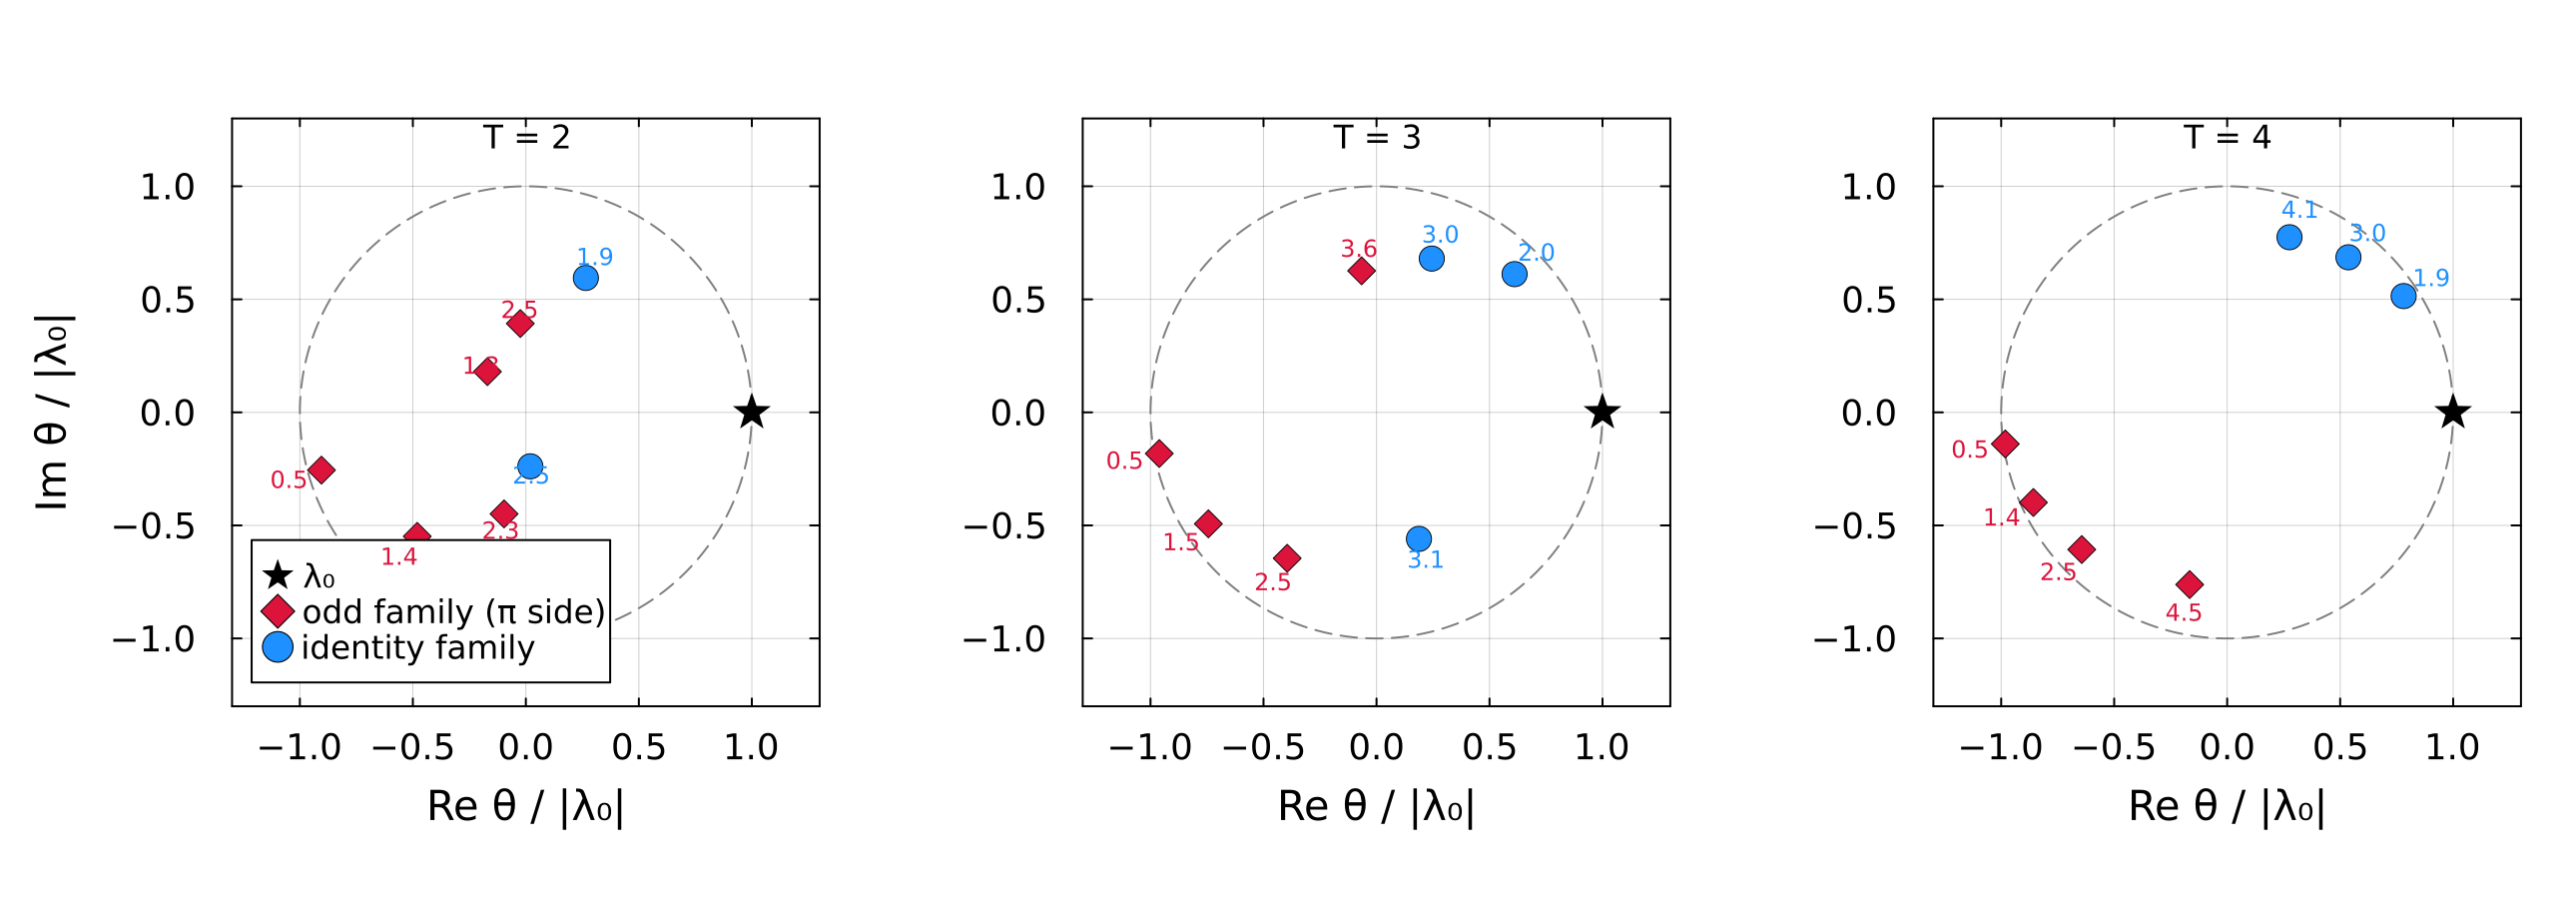

In [9]:
stress = load("../results/data/nb3_p01_stress.jld2", "done")
k8T = sort([k[2] for k in keys(stress) if k[1] == 0.1 && k[3] == 8])
v01 = V[0.1]
panels = []
for T in k8T
    e = stress[(0.1, T, 8)]
    th = collect(e.theta); i0 = argmax(abs.(th))
    lam0 = th[i0]
    pan = plot(xlabel="Re θ / |λ₀|", ylabel=(T == k8T[1] ? "Im θ / |λ₀|" : ""),
               legend=(T == k8T[1] ? :bottomleft : false), aspect_ratio=:equal,
               xlims=(-1.3, 1.3), ylims=(-1.3, 1.3))
    phis = range(0, 2pi, length=200)
    plot!(pan, cos.(phis), sin.(phis), color=:gray, ls=:dash, lw=1, label="")
    scatter!(pan, [1.0], [0.0], color=:black, marker=:star5, ms=10, label="λ₀")
    firste = true; firsto = true
    for (i, t) in enumerate(th)
        i == i0 && continue
        # divide by λ0 so the relative phase is the angle from the positive real axis
        zi = t / lam0
        g = abs(dphw(ph(t), ph(lam0)))
        even = g < pi/2
        x = even ? v01*T*g/pi : v01*T*(pi - g)/pi
        scatter!(pan, [real(zi)], [imag(zi)], color=even ? :dodgerblue : :crimson,
                 marker=even ? :circle : :diamond, ms=7, msw=0.5,
                 label=(even && firste) ? "identity family" : ((!even && firsto) ? "odd family (π side)" : ""))
        even ? (firste = false) : (firsto = false)
        annotate!(pan, 1.16*real(zi), 1.16*imag(zi), text(@sprintf("%.1f", x), 8, even ? :dodgerblue : :crimson))
    end
    annotate!(pan, 0.0, 1.22, text("T = $(Int(T))", 11))
    push!(panels, pan)
end
fig = plot(panels..., layout=(1, length(panels)), size=(430*length(panels), 460), margin=5Plots.mm, left_margin=10Plots.mm, bottom_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_tower_spectrum.png")
fig


## The tower across frustration

Boundary dimensions from the k=4 eigenvalue ladders: each captured eigenvalue is read as near-lambda0 (x = vT|dphi|/pi, even module) or pi-displaced (x = vT(pi-|dphi|)/pi, odd module). The eigenvalue-only arms extend every panel past the entropy wall.

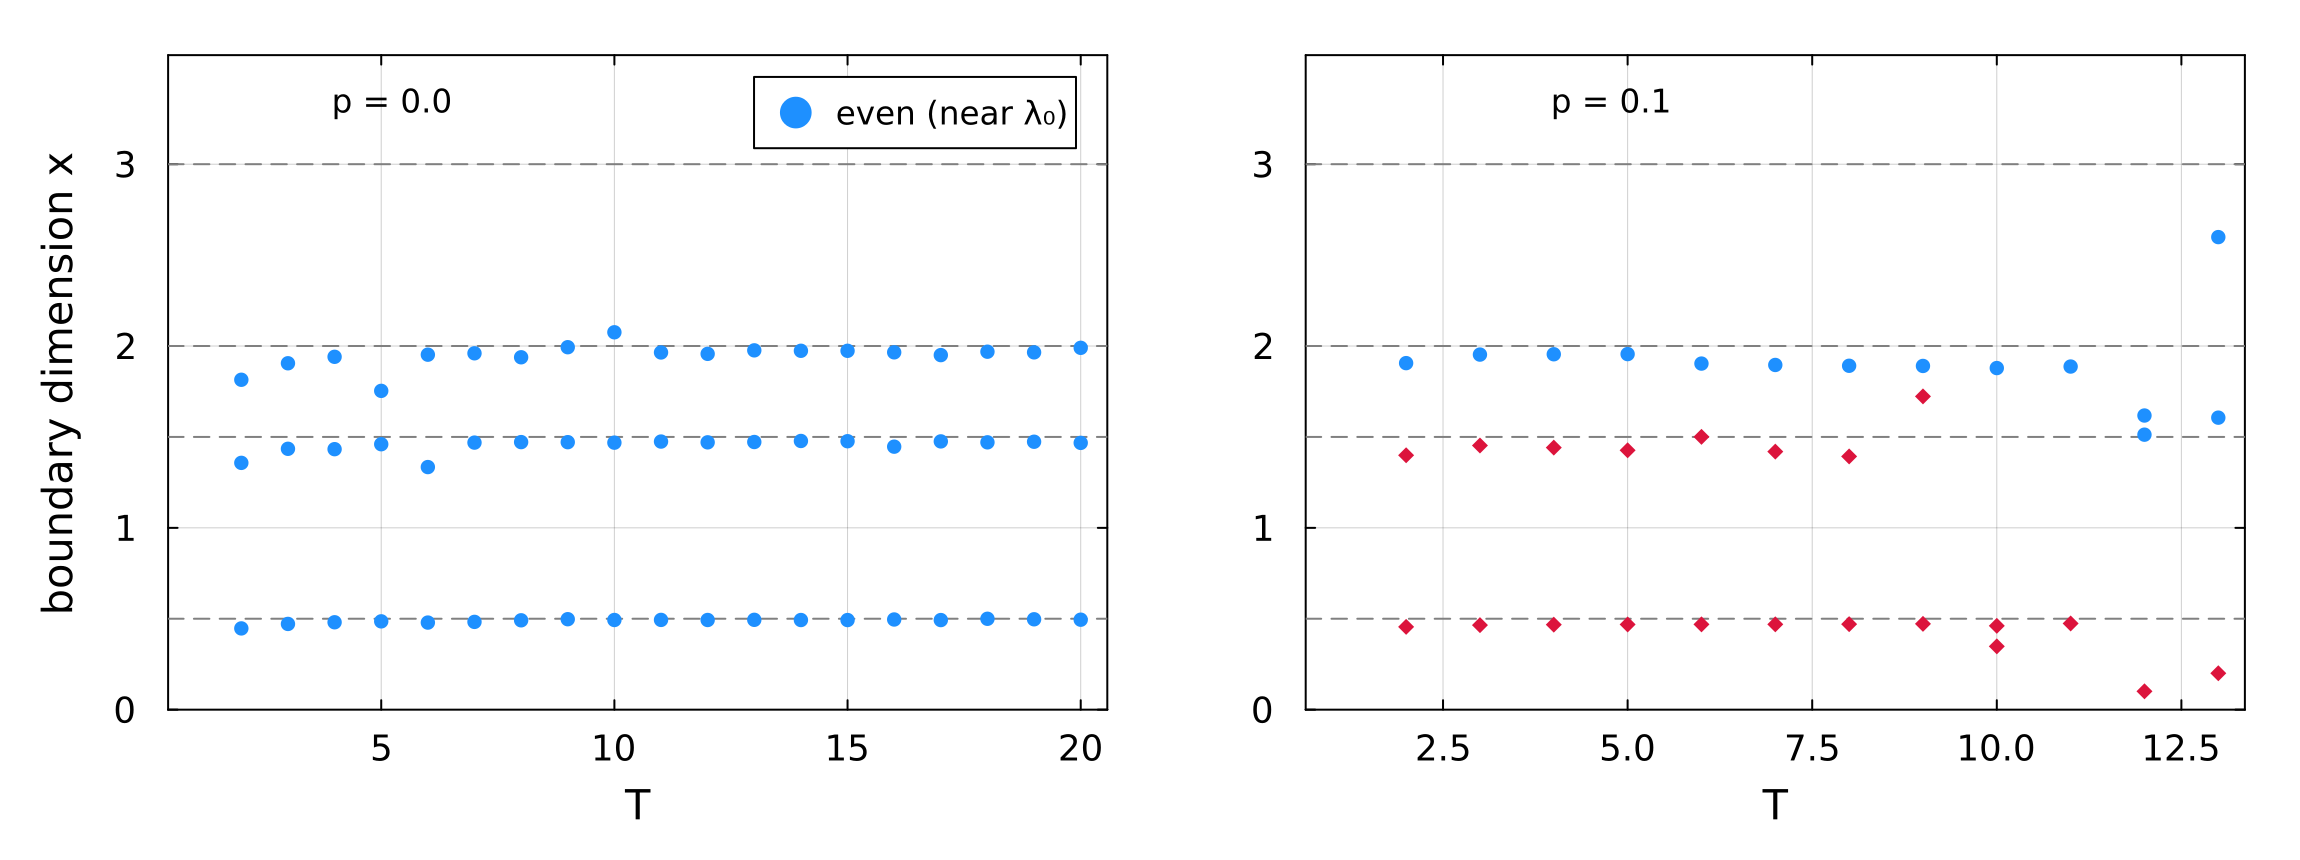

In [10]:
panels = []
for p in (0.0, 0.1)
    arm = arms[p]; chn, _, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.05, okT); okT = fb === nothing ? okT : okT[1:fb-1]
    pan = plot(xlabel="T", ylabel=p == 0.0 ? "boundary dimension x" : "",
               ylims=(0, 3.6), legend=(p == 0.0 ? :topright : false))
    for x in (0.5, 1.5, 2.0, 3.0); hline!(pan, [x], color=:gray, ls=:dash, lw=1.0, label=""); end
    firstev = true; firstodd = true
    for T in okT
        e = arm[T]; th = e.theta; i0 = chn[T]
        for (i, t) in enumerate(th)
            i == i0 && continue
            g = abs(dphw(ph(t), ph(th[i0])))
            even = g < pi/2
            x = even ? V[p] * T * g / pi : V[p] * T * (pi - g) / pi
            0.05 < x < 3.6 || continue
            scatter!(pan, [T], [x], color=even ? :dodgerblue : :crimson,
                     marker=even ? :circle : :diamond, ms=4, msw=0,
                     label=(even && firstev) ? "even (near λ₀)" : ((!even && firstodd) ? "odd (π side)" : ""))
            even ? (firstev = false) : (firstodd = false)
        end
    end
    annotate!(pan, 4.0, 3.35, text("p = $(p)", 11, :left))
    push!(panels, pan)
end
fig = plot(panels..., layout=(1,2), size=(1150, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_tower_across_p.png")
fig

## The leading spectral gap

The modulus ratio between the leading eigenvalue and the next block member, per coupling. At p=0 the companion is the first boundary rung; at p!=0 it is the pi-displaced partner, and from T~4 the two moduli agree to within two percent.

The physical branch comes from the phase tracker. Block members whose modulus exceeds it by more than 5% are unconverged outliers, so they are excluded from the choice of companion.

p=0.0  T=2–20  ratio: first=0.8898  last=0.9981  max=0.9981
p=0.1  T=2–13  ratio: first=0.9398  last=1.0201  max=1.0201


p=0.3  T=2–6  ratio: first=0.9649  last=1.0224  max=1.0224
p=0.5  T=2–3  ratio: first=0.8754  last=0.9090  max=0.9090


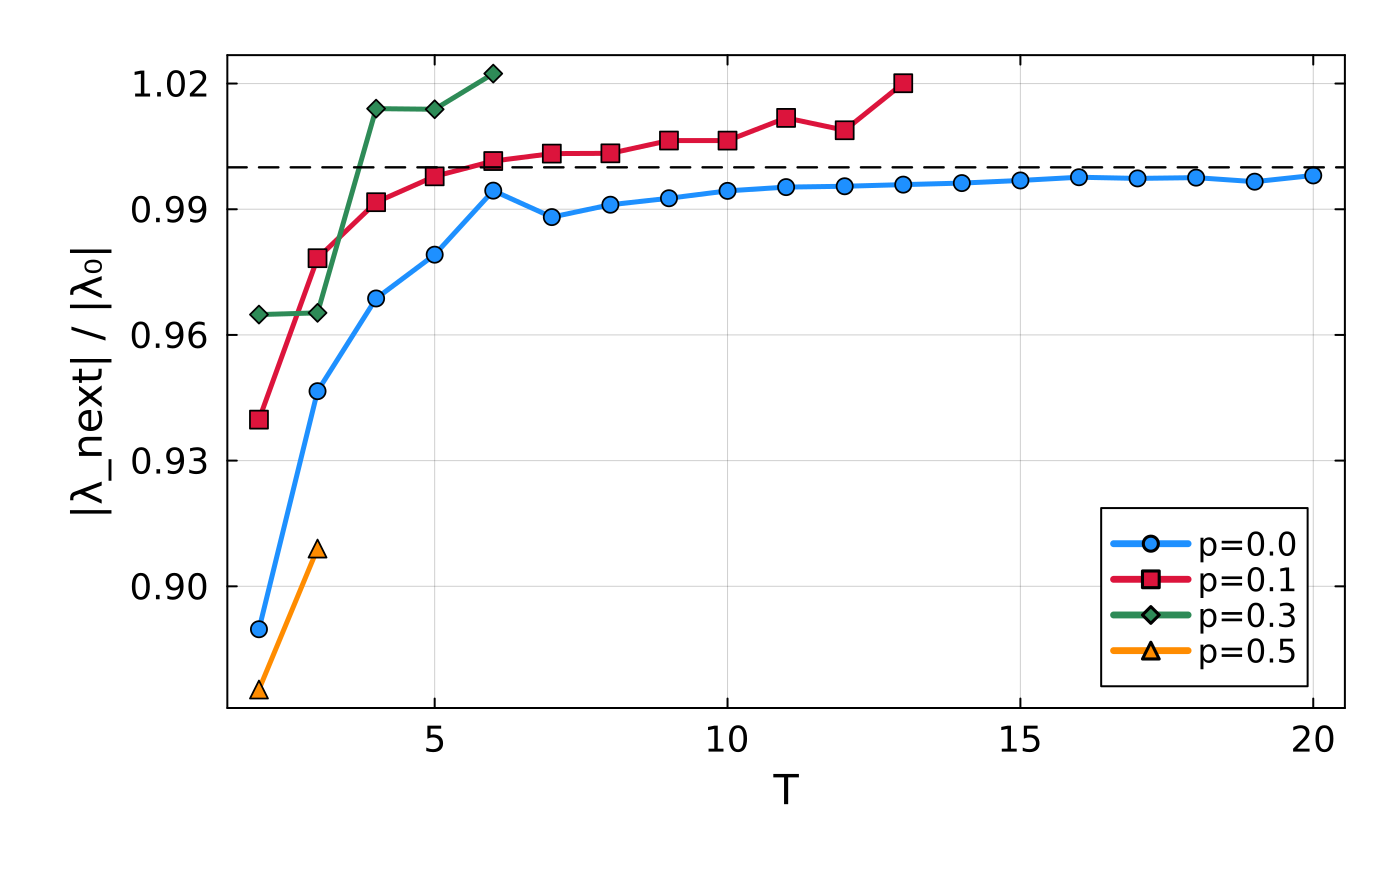

In [11]:
fig = plot(xlabel="T", ylabel="|λ_next| / |λ₀|", legend=:bottomright)
for p in (0.0, 0.1, 0.3, 0.5)
    arm = arms[p]; chn, _, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.05, okT); Ts = fb === nothing ? okT : okT[1:fb-1]
    rT = Float64[]; rv = Float64[]
    for T in Ts
        th = arm[T].theta; i0 = chn[T]
        m0 = abs(th[i0])
        cand = [abs(t) for (i, t) in enumerate(th) if i != i0 && abs(t) <= 1.05 * m0]
        isempty(cand) && continue
        push!(rT, T); push!(rv, maximum(cand) / m0)
    end
    plot!(fig, rT, rv, color=P_COLOR[p], marker=P_MARKER[p], ms=4.5, label="p=$(p)")
    @printf("p=%.1f  T=%g–%g  ratio: first=%.4f  last=%.4f  max=%.4f\n",
            p, rT[1], rT[end], rv[1], rv[end], maximum(rv))
end
hline!(fig, [1.0], color=:black, ls=:dash, lw=1.2, label="")
plot!(fig, size=(700, 440))
savefig(fig, "../results/imgs/res_partner_gap.png")
fig